<a href="https://colab.research.google.com/github/PradeepK-eng/Google-Colab-Files/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

##Gradient Calculation: Intercept (b)





In [11]:
def get_gradient_at_b(x, y, b, m):
  N = len(x)
  diff = 0
  for i in range(N):
    x_val = x[i]
    y_val = y[i]
    diff += (y_val - ((m * x_val) + b))
  b_gradient = -(2/N) * diff
  return b_gradient

##Gradient Calculation: Slope (m)

In [12]:
def get_gradient_at_m(x, y, b, m):
  N = len(x)
  diff = 0
  for i in range(N):
      x_val = x[i]
      y_val = y[i]
      diff += x_val * (y_val - ((m * x_val) + b))
  m_gradient = -(2/N) * diff
  return m_gradient

##Step_gradient function:

In [13]:
#Your step_gradient function here
def step_gradient(b_current, m_current, x, y,learning_rate):
    b_gradient = get_gradient_at_b(x, y, b_current, m_current)
    m_gradient = get_gradient_at_m(x, y, b_current, m_current)
    b = b_current - (learning_rate * b_gradient)
    m = m_current - (learning_rate * m_gradient)
    return [b, m]



##Gradient_descent function:

In [14]:
#Your gradient_descent function here:
def gradient_descent(x, y, learning_rate, num_iterations):
    b = 0
    m = 0
    for i in range(num_iterations):
        b, m = step_gradient(b, m, x, y, learning_rate)
    return [b, m]

##Input Data:

In [15]:
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
revenue = [52, 74, 79, 95, 115, 110, 129, 126, 147, 146, 156, 184]

##Calling gradient_descent function:

In [16]:
#Uncomment the line below to run your gradient_descent function
b, m = gradient_descent(months, revenue, 0.01, 1000)

##Plot:

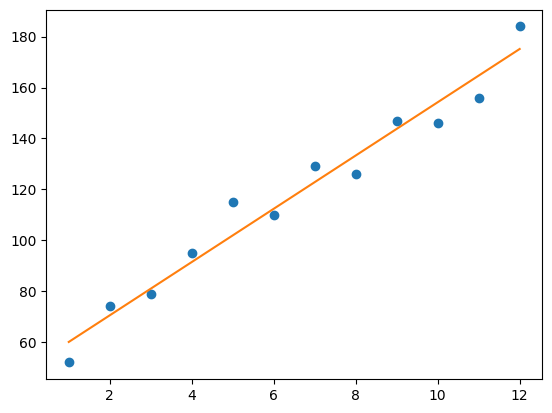

In [17]:
#Uncomment the lines below to see the line you've settled upon!
y = [m*x + b for x in months]

plt.plot(months, revenue, "o")
plt.plot(months, y)

plt.show()

Intercept (b): 50.23
Slope (m): 10.39


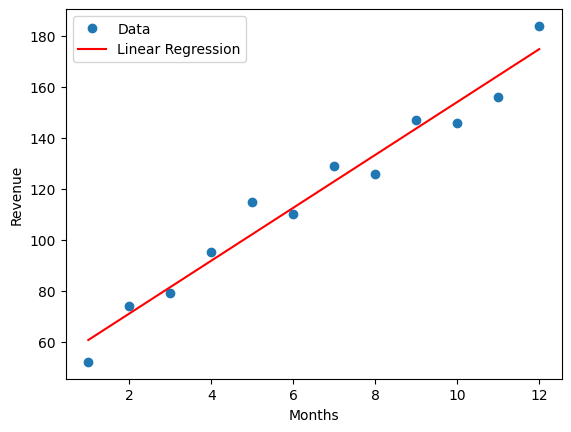

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
# from sklearn.linear_model → This tells Python to look inside the linear_model module of the scikit-learn library (a popular machine learning library).
# import LinearRegression → We specifically import the LinearRegression class


months = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]).reshape(-1, 1)
# .reshape(-1, 1) → Reshapes the months array into a 2D column vector (12 rows, 1 column).
# -1 means “figure out the correct number of rows automatically.”
# 1 means “one column.”
revenue = np.array([52, 74, 79, 95, 115, 110, 129, 126, 147, 146, 156, 184])


# Create and train LinearRegression model
model = LinearRegression()   # Creates an instance of the linear regression model.
model.fit(months, revenue)   # Trains the model using the data, months → Independent variable (X), revenue → Dependent variable (y).
# Why? The .fit() method finds the best straight line that minimizes the error between predicted and actual revenue.


# Get intercept (b) and slope (m)
b = model.intercept_ # model.intercept_ → The intercept b, , where the line crosses the y-axis.
m = model.coef_[0]   # model.coef_ → The slope(s) 𝑚, showing how much revenue changes per unit increase in month.
# [0] → Since we only have one feature (months), we take the first element.
#Why? In linear regression, the formula is: y =m.x + b, Here, m is the slope and b is the intercept.


print(f"Intercept (b): {b:.2f}")
print(f"Slope (m): {m:.2f}")
# print(f"...") → Uses an f-string for formatted output.
# {b:.2f} → Formats b to 2 decimal places.
# {m:.2f} → Formats m to 2 decimal places.
# Why? This makes the output clean and readable, showing the exact values of the regression line parameters.



# Predictions
y = model.predict(months)

# Plot the data and regression line
plt.plot(months, revenue, "o", label="Data")
plt.plot(months, y, label="Linear Regression", color="red")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.legend()
plt.show()

Estimated coefficients (true, linear regression, RANSAC):
82.1903908407869 [54.17236387] [82.08533159]


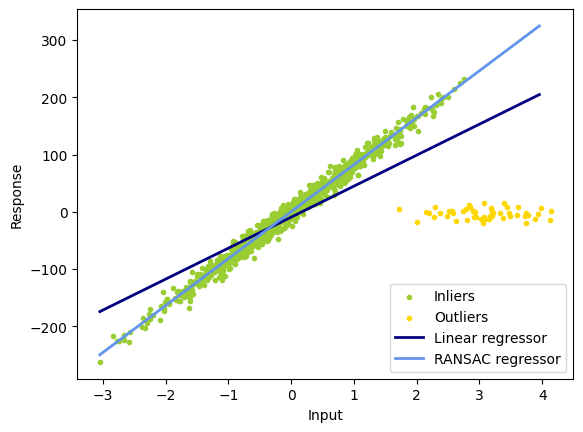

In [22]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import numpy as np
from matplotlib import pyplot as plt

from sklearn import datasets, linear_model

n_samples = 1000
n_outliers = 50


X, y, coef = datasets.make_regression(
    n_samples=n_samples,
    n_features=1,
    n_informative=1,
    noise=10,
    coef=True,
    random_state=0,
)

# Add outlier data
np.random.seed(0)
X[:n_outliers] = 3 + 0.5 * np.random.normal(size=(n_outliers, 1))
y[:n_outliers] = -3 + 10 * np.random.normal(size=n_outliers)

# Fit line using all data
lr = linear_model.LinearRegression()
lr.fit(X, y)

# Robustly fit linear model with RANSAC algorithm
ransac = linear_model.RANSACRegressor()
ransac.fit(X, y)
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# Predict data of estimated models
line_X = np.arange(X.min(), X.max())[:, np.newaxis]
line_y = lr.predict(line_X)
line_y_ransac = ransac.predict(line_X)

# Compare estimated coefficients
print("Estimated coefficients (true, linear regression, RANSAC):")
print(coef, lr.coef_, ransac.estimator_.coef_)

lw = 2
plt.scatter(
    X[inlier_mask], y[inlier_mask], color="yellowgreen", marker=".", label="Inliers"
)
plt.scatter(
    X[outlier_mask], y[outlier_mask], color="gold", marker=".", label="Outliers"
)
plt.plot(line_X, line_y, color="navy", linewidth=lw, label="Linear regressor")
plt.plot(
    line_X,
    line_y_ransac,
    color="cornflowerblue",
    linewidth=lw,
    label="RANSAC regressor",
)
plt.legend(loc="lower right")
plt.xlabel("Input")
plt.ylabel("Response")
plt.show()